# F1 Race Performance Analytics — Data Preparation & Exploration

This notebook handles the first complete data stage of the project:

- Load Australia, China and Japan race data
- Apply one reusable cleaning pipeline
- Validate the three datasets
- Explore driver, team, tyre and stint data
- Combine the three races
- Save analysis-ready CSV files

We are deliberately keeping this as **one notebook** instead of creating a separate cleaning notebook.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Project paths


In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

RACES = [
    "Australian Grand Prix",
    "Chinese Grand Prix",
    "Japanese Grand Prix"
]

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("Races:", RACES)


Project root: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics
Raw data: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\raw
Races: ['Australian Grand Prix', 'Chinese Grand Prix', 'Japanese Grand Prix']


## 2. Reusable race-loading and cleaning pipeline


In [3]:
NUMERIC_COLUMNS = [
    "time", "lap", "stint",
    "s1", "s2", "s3",
    "ms1", "ms2", "ms3",
    "life", "pos"
]

def load_and_clean_race(race_name):
    """Load and clean the session_laptimes.json for one race."""

    file_path = (
        RAW_DATA
        / race_name
        / "Race"
        / "session_laptimes.json"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Could not find: {file_path}"
        )

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # The repository's session_laptimes.json is a
    # dictionary of equal-length column arrays.
    df = pd.DataFrame(data)

    # Convert numeric fields safely.
    for column in NUMERIC_COLUMNS:
        if column in df.columns:
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            )

    # Standardize useful text fields.
    for column in ["drv", "team", "compound"]:
        if column in df.columns:
            df[column] = df[column].astype("string").str.strip()

    # Add race identifier.
    df["race"] = race_name

    # Remove exact duplicate rows.
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    duplicates_removed = before - len(df)

    print(
        f"{race_name}: "
        f"{len(df):,} rows | "
        f"{len(df.columns)} columns | "
        f"{df['drv'].nunique()} drivers | "
        f"{duplicates_removed} duplicate rows removed"
    )

    return df


## 3. Load and clean all three races


In [4]:
race_dfs = {}

for race in RACES:
    race_dfs[race] = load_and_clean_race(race)

australia_df = race_dfs["Australian Grand Prix"]
china_df = race_dfs["Chinese Grand Prix"]
japan_df = race_dfs["Japanese Grand Prix"]


Australian Grand Prix: 1,008 rows | 43 columns | 20 drivers | 0 duplicate rows removed
Chinese Grand Prix: 921 rows | 43 columns | 18 drivers | 0 duplicate rows removed
Japanese Grand Prix: 1,108 rows | 43 columns | 22 drivers | 0 duplicate rows removed


## 4. Validate that the three races have compatible schemas


In [5]:
schema_summary = pd.DataFrame({
    race: sorted(df.columns)
    for race, df in race_dfs.items()
})

print("Column count by race:")

for race, df in race_dfs.items():
    print(f"{race}: {len(df.columns)} columns")

common_columns = set(australia_df.columns)

for df in [china_df, japan_df]:
    common_columns &= set(df.columns)

print("\nCommon columns:")
print(sorted(common_columns))

for race, df in race_dfs.items():
    missing_common = sorted(common_columns - set(df.columns))

    if missing_common:
        print(f"{race} missing:", missing_common)
    else:
        print(f"{race}: schema compatible ✓")


Column count by race:
Australian Grand Prix: 43 columns
Chinese Grand Prix: 43 columns
Japanese Grand Prix: 43 columns

Common columns:
['compound', 'dNum', 'del', 'delR', 'drv', 'ff1G', 'fresh', 'iacc', 'lSD', 'lST', 'lap', 'life', 'ms1', 'ms2', 'ms3', 'pb', 'pin', 'pos', 'pout', 'race', 's1', 's1T', 's2', 's2T', 's3', 's3T', 'sesT', 'status', 'stint', 'team', 'time', 'vfl', 'vi1', 'vi2', 'vst', 'wAT', 'wH', 'wP', 'wR', 'wT', 'wTT', 'wWD', 'wWS']
Australian Grand Prix: schema compatible ✓
Chinese Grand Prix: schema compatible ✓
Japanese Grand Prix: schema compatible ✓


## 5. Combined three-race dataset


In [6]:
all_races_df = pd.concat(
    [australia_df, china_df, japan_df],
    ignore_index=True,
    sort=False
)

print("Combined shape:", all_races_df.shape)
display(all_races_df.head())


Combined shape: (3037, 43)


,time,lap,compound,stint,s1,s2,s3,ms1,ms2,ms3,life,pos,status,pb,sesT,drv,dNum,pout,pin,s1T,s2T,s3T,vi1,vi2,vfl,vst,fresh,team,lST,lSD,del,delR,ff1G,iacc,wT,wAT,wH,wP,wR,wTT,wWD,wWS,race
0,99.376,1,MEDIUM,1,NaN,19.018,39.109,77777777.0,0.0,7.700000e+01,1,12.0,1,False,3839.355,ALB,23,None,None,None,3800.705,3839.566,225.0,290.0,291.0,209.0,True,Williams,3739.743,2026-03-08T04:03:26.366000000,False,None,False,False,3793.796,24.2,54.0,1012.8,False,36.6,104,4.4,Australian Grand Prix
1,87.780,2,MEDIUM,1,31.155,18.160,38.465,100111.0,10001.0,1.011010e+09,2,13.0,1,True,3927.135,ALB,23,None,None,3870.594,3888.754,3927.219,259.0,285.0,281.0,265.0,True,Williams,3839.355,2026-03-08T04:05:05.978000000,False,None,False,True,3853.794,24.2,54.4,1012.8,False,36.0,135,2.3,Australian Grand Prix
2,87.512,3,MEDIUM,1,31.369,18.234,37.909,111100110.0,1.0,1.101100e+04,3,13.0,1,True,4014.647,ALB,23,None,None,3958.588,3976.822,4014.731,267.0,310.0,301.0,251.0,True,Williams,3927.135,2026-03-08T04:06:33.758000000,False,None,False,True,3973.816,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
3,87.911,4,MEDIUM,1,30.836,18.153,38.922,1311011.0,1.0,1.000010e+08,4,14.0,1,False,4102.558,ALB,23,None,None,4045.567,4063.72,4102.642,255.0,293.0,301.0,276.0,True,Williams,4014.647,2026-03-08T04:08:01.270000000,False,None,False,True,4033.811,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
4,87.176,5,MEDIUM,1,30.385,18.275,38.516,710011010.0,11000.0,1.010010e+09,5,13.0,1,True,4189.734,ALB,23,None,None,4133.027,4151.302,4189.818,260.0,318.0,292.0,278.0,True,Williams,4102.558,2026-03-08T04:09:29.181000000,False,None,False,True,4153.828,24.2,54.2,1012.8,False,35.1,127,2.2,Australian Grand Prix


In [7]:
print("Rows by race:")
display(
    all_races_df["race"]
    .value_counts()
    .rename_axis("race")
    .reset_index(name="rows")
)

print("\nDrivers by race:")

drivers_by_race = (
    all_races_df
    .groupby("race")["drv"]
    .nunique()
    .reset_index(name="drivers")
)

display(drivers_by_race)


Rows by race:


,race,rows
0,Japanese Grand Prix,1108
1,Australian Grand Prix,1008
2,Chinese Grand Prix,921



Drivers by race:


,race,drivers
0,Australian Grand Prix,20
1,Chinese Grand Prix,18
2,Japanese Grand Prix,22


## 6. Data-quality checks


In [8]:
quality = []

for race, df in race_dfs.items():
    quality.append({
        "race": race,
        "rows": len(df),
        "columns": len(df.columns),
        "drivers": df["drv"].nunique(),
        "teams": df["team"].nunique(),
        "duplicate_rows": df.duplicated().sum(),
        "missing_lap_time": df["time"].isna().sum(),
        "missing_driver": df["drv"].isna().sum(),
        "missing_team": df["team"].isna().sum(),
        "missing_compound": df["compound"].isna().sum()
    })

quality_df = pd.DataFrame(quality)
display(quality_df)


,race,rows,columns,drivers,teams,duplicate_rows,missing_lap_time,missing_driver,missing_team,missing_compound
0,Australian Grand Prix,1008,43,20,11,0,5,0,0,0
1,Chinese Grand Prix,921,43,18,10,0,2,0,0,0
2,Japanese Grand Prix,1108,43,22,11,0,2,0,0,0


## 7. Driver performance across all three races


In [9]:
valid_laps = all_races_df.dropna(
    subset=["time", "drv", "team"]
).copy()

driver_performance = (
    valid_laps
    .groupby(["drv", "team"])
    .agg(
        races=("race", "nunique"),
        laps=("lap", "count"),
        best_lap=("time", "min"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        lap_time_std=("time", "std")
    )
    .reset_index()
    .sort_values("average_lap")
)

display(driver_performance)


,drv,team,races,laps,best_lap,average_lap,median_lap,lap_time_std
14,NOR,McLaren,2,111,82.358,93.202018,93.3980,13.889524
4,BOR,Audi,2,110,83.257,94.018700,94.6135,13.101245
3,BEA,Haas F1 Team,3,133,84.020,94.801797,96.7780,10.994955
2,ANT,Mercedes,3,167,82.417,95.022665,94.4750,14.891825
18,RUS,Mercedes,3,167,82.670,95.132216,94.7880,14.472351
12,LEC,Ferrari,3,167,82.579,95.362240,95.1260,13.899071
9,HAM,Ferrari,3,167,82.423,95.402749,95.1660,14.304423
0,ALB,Williams,2,108,84.375,95.660611,95.0045,14.018081
21,VER,Red Bull Racing,3,156,82.091,96.178173,95.5870,14.533929
7,GAS,Alpine,3,166,84.486,96.306175,95.7595,13.489675


## 8. Performance by race


In [10]:
race_performance = (
    valid_laps
    .groupby(["race", "drv", "team"])
    .agg(
        laps=("lap", "count"),
        best_lap=("time", "min"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        lap_time_std=("time", "std")
    )
    .reset_index()
)

display(
    race_performance
    .sort_values(["race", "average_lap"])
)


,race,drv,team,laps,best_lap,average_lap,median_lap,lap_time_std
16,Australian Grand Prix,RUS,Mercedes,58,82.670,85.979328,83.1675,8.415193
2,Australian Grand Prix,ANT,Mercedes,58,82.417,86.030603,83.0910,8.860910
11,Australian Grand Prix,LEC,Ferrari,58,82.579,86.246897,83.3430,7.439266
9,Australian Grand Prix,HAM,Ferrari,58,82.423,86.257672,83.4915,7.650691
8,Australian Grand Prix,HAD,Red Bull Racing,10,85.239,86.552500,85.4040,3.344903
13,Australian Grand Prix,NOR,McLaren,58,82.358,86.871414,83.9040,8.449060
19,Australian Grand Prix,VER,Red Bull Racing,58,82.091,86.921000,83.6950,8.241412
3,Australian Grand Prix,BEA,Haas F1 Team,57,84.020,87.568316,84.8070,7.612000
12,Australian Grand Prix,LIN,Racing Bulls,57,84.182,87.695035,84.9160,7.447796
4,Australian Grand Prix,BOR,Audi,57,83.257,87.711860,84.8300,8.032040


## 9. Tyre compound analysis


In [11]:
compound_performance = (
    valid_laps
    .dropna(subset=["compound"])
    .groupby(["race", "compound"])
    .agg(
        laps=("lap", "count"),
        drivers=("drv", "nunique"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        best_lap=("time", "min")
    )
    .reset_index()
)

display(compound_performance)


,race,compound,laps,drivers,average_lap,median_lap,best_lap
0,Australian Grand Prix,HARD,588,18,87.740609,84.9355,82.091
1,Australian Grand Prix,MEDIUM,285,17,89.355379,85.6390,82.358
2,Australian Grand Prix,SOFT,130,7,103.366469,86.0670,82.926
3,Chinese Grand Prix,HARD,727,18,101.993450,98.3890,95.275
4,Chinese Grand Prix,MEDIUM,173,15,100.654422,98.3710,96.099
5,Chinese Grand Prix,SOFT,19,3,102.471316,99.1200,95.964
6,Japanese Grand Prix,HARD,609,22,102.664054,94.8720,92.432
7,Japanese Grand Prix,MEDIUM,493,22,98.545572,96.7590,93.427
8,Japanese Grand Prix,SOFT,4,1,120.247250,118.5595,116.651


## 10. Stint analysis


In [12]:
stint_performance = (
    valid_laps
    .dropna(subset=["stint", "compound"])
    .groupby(["race", "drv", "stint", "compound"])
    .agg(
        laps=("lap", "count"),
        average_lap=("time", "mean"),
        best_lap=("time", "min"),
        average_tyre_life=("life", "mean")
    )
    .reset_index()
)

display(stint_performance.head(50))


,race,drv,stint,compound,laps,average_lap,best_lap,average_tyre_life
0,Australian Grand Prix,ALB,1,MEDIUM,12,91.562750,85.558,6.5
1,Australian Grand Prix,ALB,2,HARD,21,90.294381,85.035,11.0
2,Australian Grand Prix,ALB,3,SOFT,24,85.330875,84.375,12.5
3,Australian Grand Prix,ALO,1,SOFT,11,91.645364,86.792,6.0
4,Australian Grand Prix,ALO,2,SOFT,2,595.935500,122.340,1.5
5,Australian Grand Prix,ALO,3,SOFT,8,88.227375,85.713,6.5
6,Australian Grand Prix,ANT,1,MEDIUM,12,89.377250,83.683,6.5
7,Australian Grand Prix,ANT,2,HARD,46,85.157565,82.417,23.5
8,Australian Grand Prix,BEA,1,MEDIUM,18,91.169833,84.562,9.5
9,Australian Grand Prix,BEA,2,HARD,39,85.906077,84.020,20.0


## 11. Tyre-age / degradation analysis


In [13]:
degradation = (
    valid_laps
    .dropna(subset=["life"])
    .groupby(["race", "compound", "life"])
    .agg(
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        observations=("time", "count")
    )
    .reset_index()
)

display(degradation.head(30))


,race,compound,life,average_lap,median_lap,observations
0,Australian Grand Prix,HARD,1,109.107550,116.0420,20
1,Australian Grand Prix,HARD,2,91.887200,86.7535,20
2,Australian Grand Prix,HARD,3,84.996650,84.9810,20
3,Australian Grand Prix,HARD,4,85.152350,84.6255,20
4,Australian Grand Prix,HARD,5,85.223800,84.9245,20
5,Australian Grand Prix,HARD,6,87.608150,85.4595,20
6,Australian Grand Prix,HARD,7,94.821050,87.2750,20
7,Australian Grand Prix,HARD,8,92.762650,86.5910,20
8,Australian Grand Prix,HARD,9,87.024800,85.0695,20
9,Australian Grand Prix,HARD,10,85.300250,84.6925,20


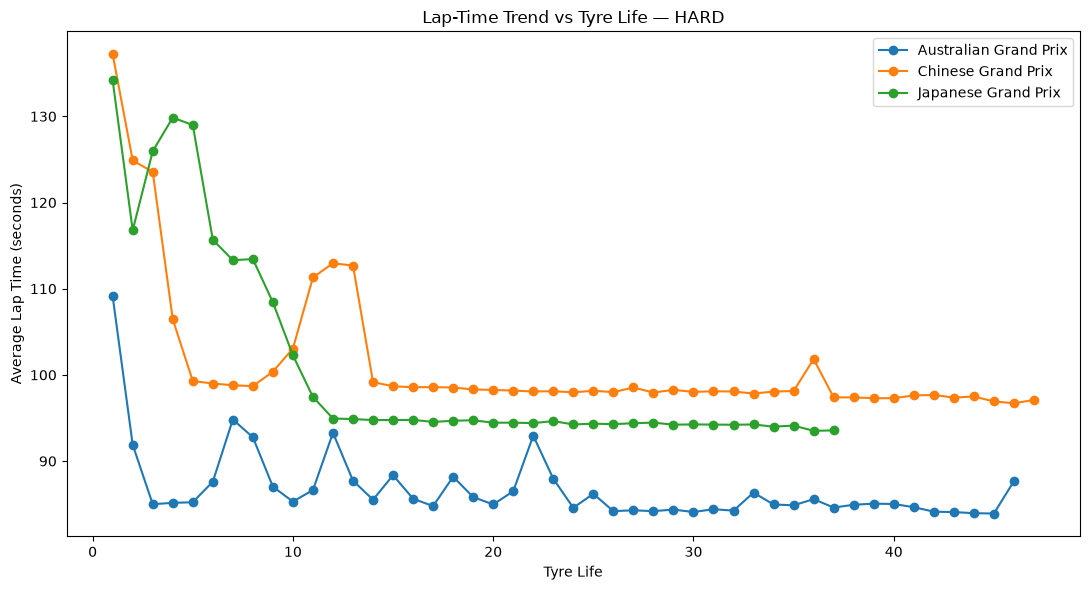

In [14]:
# Show the tyre-age relationship for the most common compound.
if not degradation.empty:
    common_compound = (
        valid_laps["compound"]
        .value_counts()
        .index[0]
    )

    plot_df = degradation[
        degradation["compound"] == common_compound
    ]

    plt.figure(figsize=(11, 6))

    for race in RACES:
        temp = plot_df[plot_df["race"] == race]

        if not temp.empty:
            plt.plot(
                temp["life"],
                temp["average_lap"],
                marker="o",
                label=race
            )

    plt.xlabel("Tyre Life")
    plt.ylabel("Average Lap Time (seconds)")
    plt.title(
        f"Lap-Time Trend vs Tyre Life — {common_compound}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


## 12. Driver consistency


In [15]:
driver_consistency = (
    valid_laps
    .groupby(["race", "drv", "team"])
    .agg(
        average_lap=("time", "mean"),
        lap_time_std=("time", "std"),
        laps=("time", "count")
    )
    .reset_index()
    .sort_values(["race", "lap_time_std"])
)

display(driver_consistency)


,race,drv,team,average_lap,lap_time_std,laps
8,Australian Grand Prix,HAD,Red Bull Racing,86.552500,3.344903,10
14,Australian Grand Prix,OCO,Haas F1 Team,88.011421,7.287612,57
7,Australian Grand Prix,GAS,Alpine,87.996982,7.351476,57
11,Australian Grand Prix,LEC,Ferrari,86.246897,7.439266,58
12,Australian Grand Prix,LIN,Racing Bulls,87.695035,7.447796,57
3,Australian Grand Prix,BEA,Haas F1 Team,87.568316,7.612000,57
9,Australian Grand Prix,HAM,Ferrari,86.257672,7.650691,58
15,Australian Grand Prix,PER,Cadillac,90.811836,7.852015,55
4,Australian Grand Prix,BOR,Audi,87.711860,8.032040,57
0,Australian Grand Prix,ALB,Williams,88.471509,8.111483,57


## 13. Save processed datasets


In [16]:
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

for race, df in race_dfs.items():
    filename = (
        race.lower()
        .replace(" grand prix", "")
        .replace(" ", "_")
        + "_race_laptimes.csv"
    )

    output_path = PROCESSED_DATA / filename
    df.to_csv(output_path, index=False)

    print("Saved:", output_path)

combined_path = PROCESSED_DATA / "f1_2026_three_races.csv"
all_races_df.to_csv(combined_path, index=False)

print("\nSaved combined dataset:")
print(combined_path)


Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\australian_race_laptimes.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\chinese_race_laptimes.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\japanese_race_laptimes.csv

Saved combined dataset:
c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\f1_2026_three_races.csv


## 14. Final project-ready dataset summary


In [17]:
print("=" * 65)
print("F1 2026 — THREE-RACE DATASET")
print("=" * 65)

print(f"Total rows: {len(all_races_df):,}")
print(f"Total columns: {len(all_races_df.columns)}")
print(f"Races: {all_races_df['race'].nunique()}")
print(f"Drivers: {all_races_df['drv'].nunique()}")
print(f"Teams: {all_races_df['team'].nunique()}")

print("\nRows per race:")
print(all_races_df["race"].value_counts())

print("\nMissing lap times:")
print(all_races_df["time"].isna().sum())

print("\nExact duplicate rows:")
print(all_races_df.duplicated().sum())


F1 2026 — THREE-RACE DATASET
Total rows: 3,037
Total columns: 43
Races: 3
Drivers: 22
Teams: 11

Rows per race:
race
Japanese Grand Prix      1108
Australian Grand Prix    1008
Chinese Grand Prix        921
Name: count, dtype: int64

Missing lap times:
9

Exact duplicate rows:
0
